# Breast Tumor Segmentation using U-Net

This project implements a deep learning-based U-Net architecture to perform semantic segmentation on breast ultrasound images. 

The goal is to automatically detect and localize tumor regions at the pixel level using convolutional neural networks.

---

### Dataset
Breast Ultrasound Images Dataset (BUSI)

- 647 ultrasound images (benign + malignant)
- Ground-truth segmentation masks
- Images resized to 128×128 grayscale

---

### Model Overview
- U-Net architecture with encoder-decoder structure
- Batch Normalization for stable training
- Dropout for regularization
- Combined Binary Crossentropy + Dice loss
- EarlyStopping and ReduceLROnPlateau callbacks


## Problem Statement

Breast cancer is one of the most common cancers worldwide. Ultrasound imaging is widely used for early tumor detection due to its safety and accessibility.

The objective of this project is to build a deep learning model capable of segmenting tumor regions from breast ultrasound images.

Instead of simply predicting whether a tumor is present, the model performs pixel-level segmentation to identify the exact tumor location.

---

## Why Segmentation Instead of Classification?

A classification model only predicts whether an image is benign or malignant.

However, in medical imaging:
- Tumor size matters
- Tumor shape matters
- Tumor boundary clarity matters

Segmentation provides:
- Precise tumor localization
- Better interpretability
- Quantitative area estimation

Therefore, semantic segmentation is more clinically meaningful than classification.

---

## Why Dice Coefficient Instead of Accuracy?

In medical segmentation, background pixels dominate the image.

If a model predicts all pixels as background:
- Pixel accuracy can still be very high
- Tumor detection completely fails

Dice coefficient measures overlap between predicted tumor mask and ground truth mask:

Dice = (2 × Intersection) / (Total Predicted + Total True)

This makes Dice a more reliable evaluation metric for segmentation tasks.


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)


In [2]:
dataset_path = "../data/Dataset_BUSI_with_GT"


In [3]:
image_size = 128
images = []
masks = []

for folder in ['benign', 'malignant']:
    folder_path = os.path.join(dataset_path, folder)

    for file in os.listdir(folder_path):
        if "mask" not in file:
            img_path = os.path.join(folder_path, file)
            mask_path = os.path.join(folder_path, file.replace(".png", "_mask.png"))

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (image_size, image_size))
            img = img / 255.0

            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (image_size, image_size))
            mask = mask / 255.0
            mask = np.expand_dims(mask, axis=-1)

            images.append(img)
            masks.append(mask)

X = np.array(images)
y = np.array(masks)
X = np.expand_dims(X, axis=-1)

print("Total Images:", len(X))
print("Shape:", X.shape)


Total Images: 647
Shape: (647, 128, 128, 1)


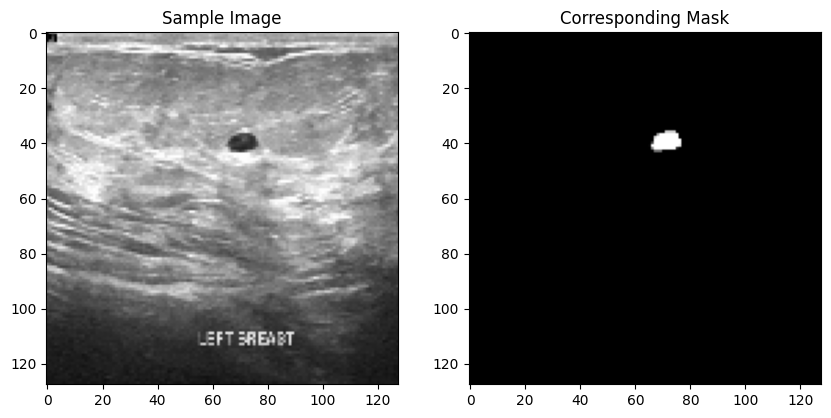

In [4]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.title("Sample Image")
plt.imshow(X[0].squeeze(), cmap='gray')

plt.subplot(1,2,2)
plt.title("Corresponding Mask")
plt.imshow(y[0].squeeze(), cmap='gray')

plt.show()


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (517, 128, 128, 1)
Test: (130, 128, 128, 1)


In [6]:
def conv_block(x, filters):
    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(filters, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    return x


In [7]:
def build_unet(input_shape=(128,128,1)):

    inputs = Input(input_shape)

    # Encoder
    c1 = conv_block(inputs, 32)
    p1 = MaxPooling2D()(c1)

    c2 = conv_block(p1, 64)
    p2 = MaxPooling2D()(c2)

    c3 = conv_block(p2, 128)
    p3 = MaxPooling2D()(c3)

    # Bottleneck
    b1 = conv_block(p3, 256)
    b1 = Dropout(0.3)(b1)

    # Decoder
    u1 = UpSampling2D()(b1)
    u1 = Concatenate()([u1, c3])
    c4 = conv_block(u1, 128)

    u2 = UpSampling2D()(c4)
    u2 = Concatenate()([u2, c2])
    c5 = conv_block(u2, 64)

    u3 = UpSampling2D()(c5)
    u3 = Concatenate()([u3, c1])
    c6 = conv_block(u3, 32)

    outputs = Conv2D(1, 1, activation='sigmoid')(c6)

    model = Model(inputs, outputs)
    return model


In [8]:
model = build_unet()
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_4[0][0]  

 Total params: 1,951,937 (7.45 MB)

 Trainable params: 1,949,121 (7.44 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [9]:
def dice_coefficient(y_true, y_pred):
    smooth = 1
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (
        tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth
    )

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    dice = 1 - dice_coefficient(y_true, y_pred)
    return bce + dice


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss,
    metrics=[dice_coefficient]
)


In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]


In [12]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=16,
    callbacks=callbacks
)


Epoch 1/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - dice_coefficient: 0.2171 - loss: 1.3303 - val_dice_coefficient: 0.1563 - val_loss: 1.4994 - learning_rate: 1.0000e-04
Epoch 2/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - dice_coefficient: 0.3037 - loss: 1.0900 - val_dice_coefficient: 0.1519 - val_loss: 1.4451 - learning_rate: 1.0000e-04
Epoch 3/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - dice_coefficient: 0.3532 - loss: 0.9656 - val_dice_coefficient: 0.1452 - val_loss: 1.3795 - learning_rate: 1.0000e-04
Epoch 4/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - dice_coefficient: 0.3890 - loss: 0.8926 - val_dice_coefficient: 0.1416 - val_loss: 1.3441 - learning_rate: 1.0000e-04
Epoch 5/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - dice_coefficient: 0.4185 - loss: 0.8374 - val_dice_coefficient: 0.1441 - val_loss: 1.3096 - learning_rate: 1.0000e-04
Epoch 6/40
33/33 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - dice_coefficient: 0.4493 - loss: 0.7815 - val_dice_coefficient: 0.1448 - val_loss: 1.2432 - learni

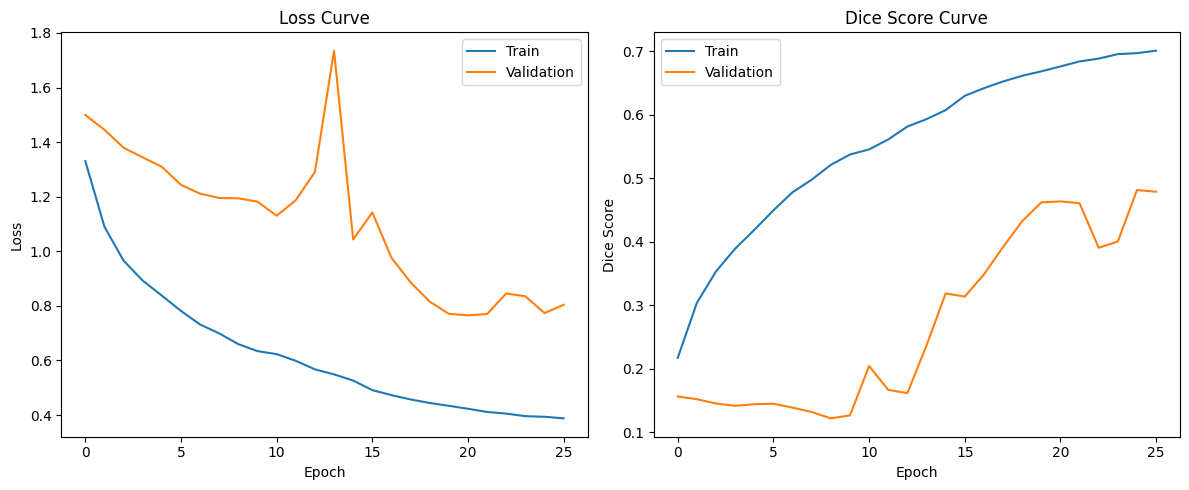

In [13]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['dice_coefficient'])
plt.plot(history.history['val_dice_coefficient'])
plt.title("Dice Score Curve")
plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.legend(["Train","Validation"])

plt.tight_layout()

plt.savefig("../outputs/training_curves.png", dpi=300, bbox_inches='tight')
plt.show()


In [14]:
results = model.evaluate(X_test, y_test)

print("Model Evaluation Summary")
print("------------------------")
print(f"Validation Dice Coefficient: {results[1]:.4f}")
print(f"Validation Loss: {results[0]:.4f}")


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 551ms/step - dice_coefficient: 0.4782 - loss: 0.7639
Model Evaluation Summary
------------------------
Validation Dice Coefficient: 0.4782
Validation Loss: 0.7639


In [15]:
preds = model.predict(X_test)
preds_binary = (preds > 0.5).astype(np.float32)


5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 670ms/step


In [16]:
dice_scores = []

for i in range(len(X_test)):
    intersection = np.sum(y_test[i] * preds_binary[i])
    dice = (2. * intersection) / (np.sum(y_test[i]) + np.sum(preds_binary[i]) + 1e-7)
    dice_scores.append(dice)

print(f"Binary Dice Average: {np.mean(dice_scores):.4f}")


Binary Dice Average: 0.5531


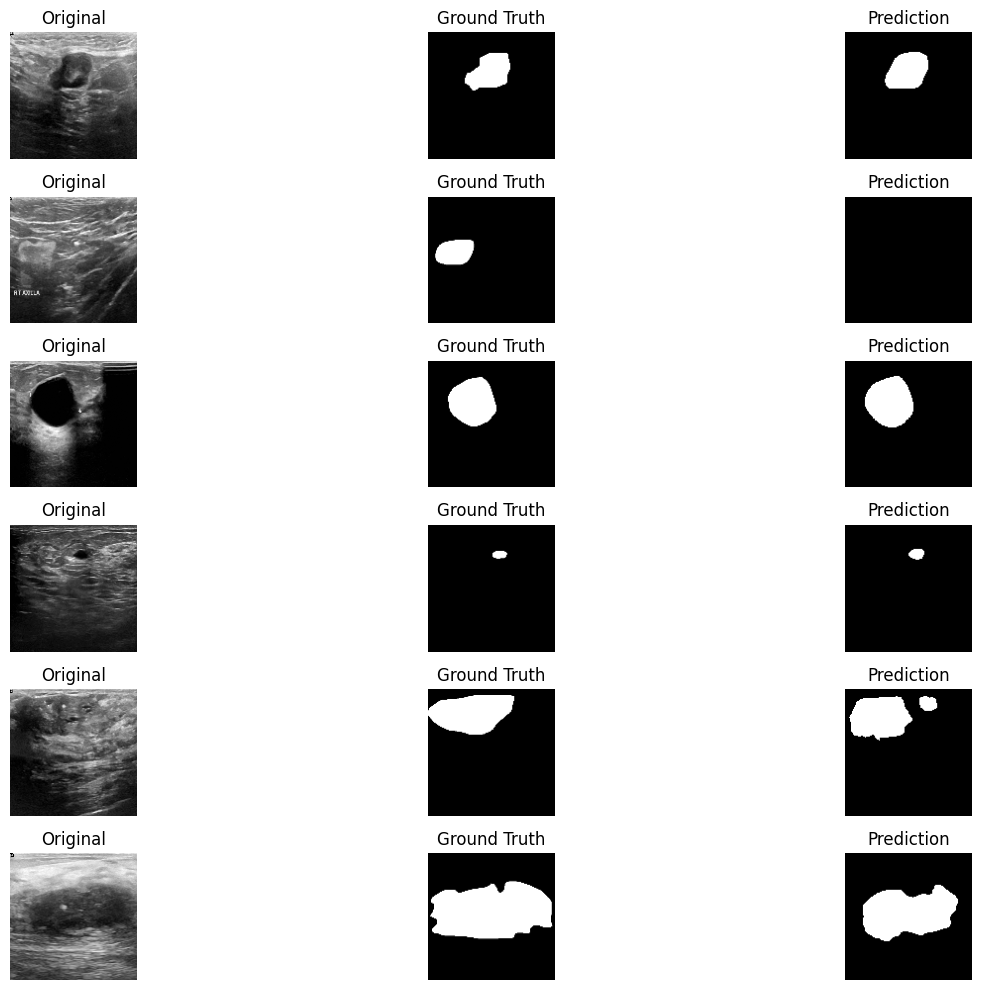

In [17]:
num_samples = 6
plt.figure(figsize=(15,10))

for i in range(num_samples):
    plt.subplot(num_samples, 3, 3*i+1)
    plt.imshow(X_test[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(num_samples, 3, 3*i+2)
    plt.imshow(y_test[i].squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(num_samples, 3, 3*i+3)
    plt.imshow(preds_binary[i].squeeze(), cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()

plt.savefig("../outputs/prediction_samples.png", dpi=300, bbox_inches='tight')
plt.show()


In [18]:
model.save("../models/unet_breast_cancer_model.h5")


In [19]:
pixel_acc = np.mean(preds_binary == y_test)
print("Pixel Accuracy:", pixel_acc)


Pixel Accuracy: 0.9379770132211539


In [20]:
def calculate_iou(y_true, y_pred):
    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection
    return intersection / (union + 1e-7)


In [21]:
iou_scores = []

for i in range(len(X_test)):
    iou = calculate_iou(y_test[i], preds_binary[i])
    iou_scores.append(iou)

print("Average IoU:", np.mean(iou_scores))


Average IoU: 0.4477208024943513


## Model Limitations

- The dataset is relatively small (~647 images), which limits generalization.
- Tumor regions occupy a small portion of the image, creating class imbalance.
- No external validation dataset was used.
- The model may overfit to training distribution.
- This implementation is for research and educational purposes only and is not suitable for clinical diagnosis.


## Future Improvements

- Implement Attention U-Net for improved feature localization.
- Use pretrained encoder (e.g., ResNet-based U-Net) for better feature extraction.
- Apply stronger data augmentation techniques.
- Perform k-fold cross-validation for robustness.
- Train on larger, multi-institution datasets.
- Conduct proper clinical validation studies.
